In [1]:
import sys
from pathlib import Path

current_dir = Path.cwd()

def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'pyproject.toml').exists() and (p / 'bcosgnn').is_dir():
            return p
    raise RuntimeError('Could not locate repo root (pyproject.toml + bcosgnn/).')

project_root = find_repo_root(current_dir)

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print(f"Repo root added: {project_root}")

Repo root added: /home/moso00002/Desktop/gnn/bcosgnn-bcos_gnn_shaique


# BCos-GINE on ZINC+Dichlorobenzene (Ortho/Meta/Para)
This notebook trains an **edge-aware BCos-GINE** classifier (3 classes) on the semi-synthetic `zinc_dichloro` dataset, then evaluates **BCos gradient explanations** with **Retrieval AUROC** and **Jaccard@k** against the provided ground-truth motif masks.

In [ ]:
import random
from collections import defaultdict
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.metrics import roc_auc_score
from torch_geometric.loader import DataLoader
from torch_geometric.utils import to_networkx
from torch_geometric.nn.conv import GINEConv
from torch_geometric.nn.aggr import MeanAggregation

from tqdm.auto import tqdm

from bcos.modules import BcosLinear
from bcosgnn.explain_edge_attr import explain as explain_edge_attr

In [5]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEVICE

device(type='cuda')

In [6]:
SPLITS_PATH = project_root / 'data/zinc_dichloro/processed/splits.pt'
assert SPLITS_PATH.exists(), f"Missing {SPLITS_PATH}. Run scripts/build_zinc_dichloro_dataset.py first."

splits = torch.load(SPLITS_PATH, weights_only=False)
train_data = splits['train']
val_data = splits['val']
test_data = splits['test']

len(train_data), len(val_data), len(test_data)

(4800, 600, 600)

In [7]:
def class_counts(dataset):
    counts = defaultdict(int)
    for d in dataset:
        counts[int(d.y)] += 1
    return dict(sorted(counts.items()))

print('train', class_counts(train_data))
print('val  ', class_counts(val_data))
print('test ', class_counts(test_data))

train {0: 1600, 1: 1600, 2: 1600}
val   {0: 200, 1: 200, 2: 200}
test  {0: 200, 1: 200, 2: 200}


In [8]:
# label mapping used by builder: 0=ortho, 1=meta, 2=para
LABELS = {0: 'ortho', 1: 'meta', 2: 'para'}

In [9]:
def to_undirected_edge_index(edge_index: torch.Tensor):
    # edge_index: [2, E] directed, make undirected by sorting and unique
    src = edge_index[0].cpu().numpy()
    dst = edge_index[1].cpu().numpy()
    a = np.minimum(src, dst)
    b = np.maximum(src, dst)
    pairs = np.stack([a, b], axis=1)
    pairs = np.unique(pairs, axis=0)
    return pairs


def plot_graph_with_mask(data, node_score=None, title=None, ax=None):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 4))
    G = to_networkx(data, to_undirected=True)

    # layout: try to mimic hexagon for ring if node_mask_full exists
    pos = None
    if hasattr(data, 'node_mask_full') and data.node_mask_full is not None:
        ring_nodes = torch.where(data.node_mask_full.bool())[0].cpu().tolist()
        # heuristic: use the 6 ring nodes = nodes with degree 2 among mask_full?
        # simplest: just use spring but seed for stability
        pos = nx.spring_layout(G, seed=0)
    else:
        pos = nx.spring_layout(G, seed=0)

    node_colors = []
    for i in range(data.num_nodes):
        if hasattr(data, 'node_mask_full') and bool(data.node_mask_full[i].item()):
            node_colors.append('tab:orange')
        else:
            node_colors.append('lightgray')

    node_sizes = []
    for i in range(data.num_nodes):
        if node_score is None:
            node_sizes.append(120)
        else:
            s = float(node_score[i])
            node_sizes.append(60 + 400 * s)

    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.4, width=1.0)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=node_sizes, linewidths=0.5, edgecolors='k')
    ax.set_axis_off()
    if title is not None:
        ax.set_title(title)
    return ax

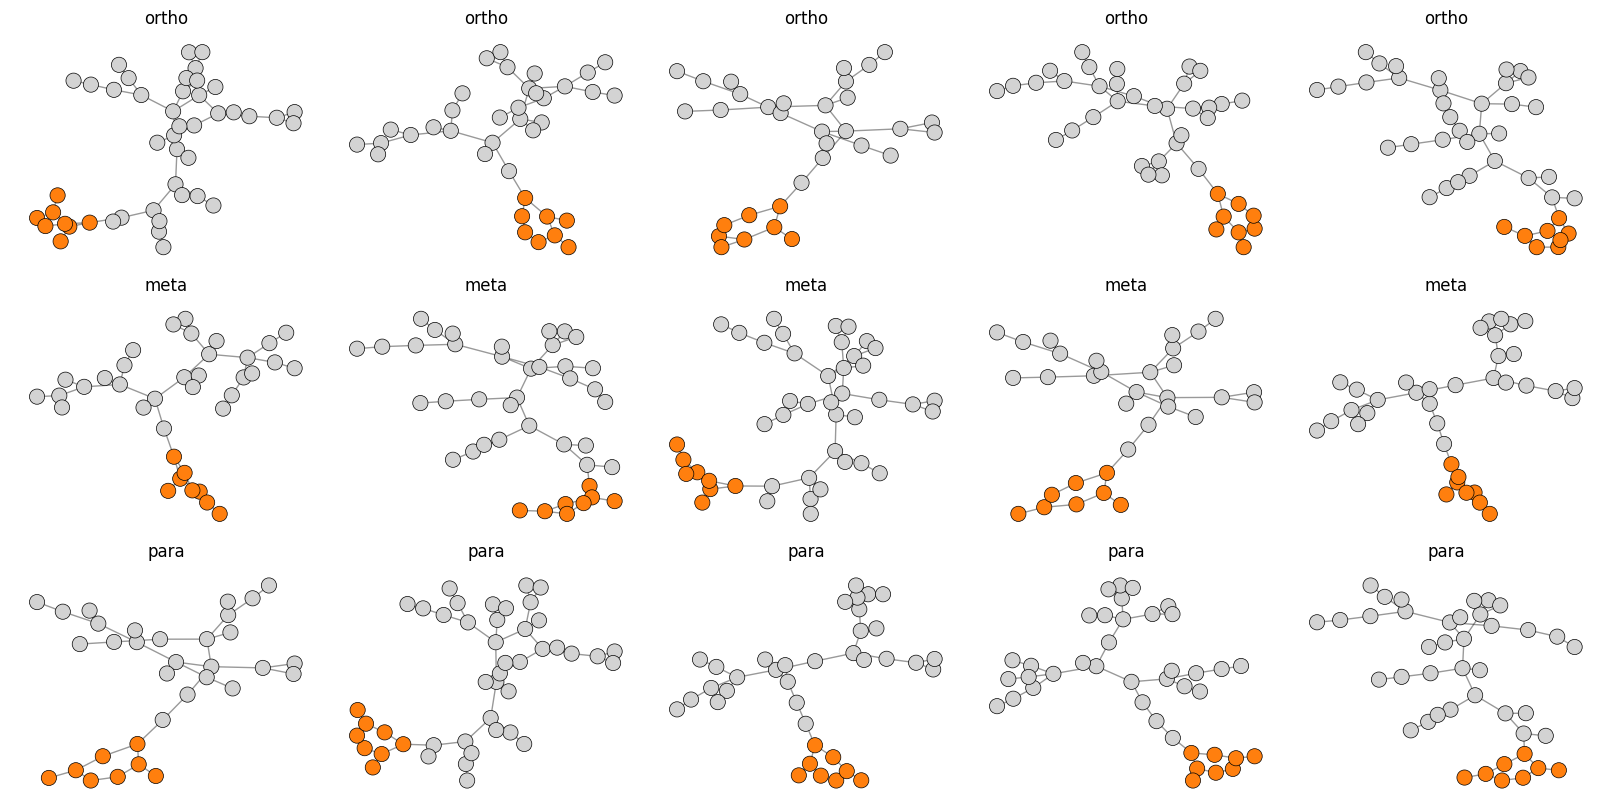

In [8]:
def sample_indices_by_class(dataset, n_per_class=5, seed=0):
    rng = random.Random(seed)
    by_class = defaultdict(list)
    for i, d in enumerate(dataset):
        by_class[int(d.y)].append(i)
    out = {}
    for c in sorted(by_class):
        idxs = by_class[c][:]
        rng.shuffle(idxs)
        out[c] = idxs[:n_per_class]
    return out

idxs = sample_indices_by_class(train_data, n_per_class=5, seed=0)
fig, axes = plt.subplots(len(LABELS), 5, figsize=(16, 8), constrained_layout=True)
for row, c in enumerate(sorted(LABELS)):
    for col, i in enumerate(idxs[c]):
        d = train_data[i]
        plot_graph_with_mask(d, title=f"{LABELS[c]}", ax=axes[row, col])
plt.show()

In [10]:
# Data loaders
BATCH_SIZE = 64
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

node_dim = int(train_data[0].x.size(-1))
edge_dim = int(train_data[0].edge_attr.size(-1))
num_classes = 3
node_dim, edge_dim, num_classes

(7, 6, 3)

## BCos GINE (edge-aware)
This section defines a BCos version of GINE (uses `edge_attr`) 

In [11]:
# 4-layer BCos-GINE for `zinc_dichloro` (continuous x and edge_attr)
class BCosGINE(nn.Module):
    def __init__(
        self,
        node_dim: int,
        edge_dim: int,
        *,
        hidden_dim: int = 128,
        num_layers: int = 4,
        num_classes: int = 3,
        b: float = 2.0,
        max_out: int = 1,
        dropout: float = 0.5,
    ):
        super().__init__()
        self.lin_node = BcosLinear(node_dim, hidden_dim, b=b, max_out=max_out)
        self.lin_edge = BcosLinear(edge_dim, hidden_dim, b=b, max_out=max_out)
        self.convs = nn.ModuleList([
            GINEConv(BcosLinear(hidden_dim, hidden_dim, b=b, max_out=max_out), train_eps=False)
            for _ in range(num_layers)
        ])
        self.norms = nn.ModuleList([nn.BatchNorm1d(hidden_dim) for _ in range(num_layers)])
        self.agg = MeanAggregation()
        self.dropout = nn.Dropout(dropout)
        self.head = BcosLinear(hidden_dim, num_classes, b=b, max_out=max_out)

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor, edge_attr: torch.Tensor, batch: torch.Tensor) -> torch.Tensor:
        x = self.lin_node(x)
        edge_attr = self.lin_edge(edge_attr)
        for conv, bn in zip(self.convs, self.norms):
            x = conv(x, edge_index, edge_attr)
            x = bn(x)
            x = F.relu(x)
        g = self.agg(x, batch)
        g = self.dropout(g)
        return self.head(g)  # [num_graphs, num_classes]

In [12]:
# Instantiate model
model = BCosGINE(node_dim=node_dim, edge_dim=edge_dim, hidden_dim=128, num_layers=4, num_classes=num_classes).to(DEVICE)
model

BCosGINE(
  (lin_node): BcosLinear(
    B=2.0,
    (linear): NormedLinear(in_features=7, out_features=128, bias=False)
  )
  (lin_edge): BcosLinear(
    B=2.0,
    (linear): NormedLinear(in_features=6, out_features=128, bias=False)
  )
  (convs): ModuleList(
    (0-3): 4 x GINEConv(nn=BcosLinear(
      B=2.0,
      (linear): NormedLinear(in_features=128, out_features=128, bias=False)
    ))
  )
  (norms): ModuleList(
    (0-3): 4 x BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (agg): MeanAggregation()
  (dropout): Dropout(p=0.5, inplace=False)
  (head): BcosLinear(
    B=2.0,
    (linear): NormedLinear(in_features=128, out_features=3, bias=False)
  )
)

In [ ]:
def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    total_loss = 0.0
    total_correct = 0
    total_graphs = 0
    for batch in loader:
        batch = batch.to(DEVICE)
        logits = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
        loss = F.cross_entropy(logits, batch.y)
        if is_train:
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()
        total_loss += float(loss) * batch.num_graphs
        total_correct += int((logits.argmax(dim=-1) == batch.y).sum().item())
        total_graphs += int(batch.num_graphs)
    return total_loss / max(1, total_graphs), total_correct / max(1, total_graphs)

LR = 1e-3
EPOCHS = 200
EARLY_STOP_PATIENCE = 20
SCHEDULER_FACTOR = 0.5
SCHEDULER_MIN_LR = 1e-6
SCHEDULER_PATIENCE = 5

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=SCHEDULER_FACTOR, patience=SCHEDULER_PATIENCE, min_lr=SCHEDULER_MIN_LR
)

best_val = float('inf')
best_state = None
bad_epochs = 0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, optimizer=optimizer)
    with torch.no_grad():
        val_loss, val_acc = run_epoch(model, val_loader)
    scheduler.step(val_loss)
    lr_now = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch:03d} | lr={lr_now:.2e} | train loss={train_loss:.4f} acc={train_acc:.4f} | val loss={val_loss:.4f} acc={val_acc:.4f}")
    if val_loss < best_val - 1e-6:
        best_val = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        bad_epochs = 0
    else:
        bad_epochs += 1
        if bad_epochs >= EARLY_STOP_PATIENCE:
            print(f"Early stopping at epoch {epoch} (best val loss={best_val:.4f}).")
            break

assert best_state is not None
model.load_state_dict(best_state)

with torch.no_grad():
    test_loss, test_acc = run_epoch(model, test_loader)
print(f"Test loss={test_loss:.4f} | Test acc={test_acc:.4f}")

Epoch 001 | lr=1.00e-03 | train loss=0.5092 acc=0.8327 | val loss=0.2412 acc=0.9717
Epoch 002 | lr=1.00e-03 | train loss=0.0871 acc=1.0000 | val loss=0.0264 acc=1.0000
Epoch 002 | lr=1.00e-03 | train loss=0.0871 acc=1.0000 | val loss=0.0264 acc=1.0000
Epoch 003 | lr=1.00e-03 | train loss=0.0579 acc=1.0000 | val loss=0.0118 acc=1.0000
Epoch 003 | lr=1.00e-03 | train loss=0.0579 acc=1.0000 | val loss=0.0118 acc=1.0000
Epoch 004 | lr=1.00e-03 | train loss=0.0452 acc=1.0000 | val loss=0.0055 acc=1.0000
Epoch 004 | lr=1.00e-03 | train loss=0.0452 acc=1.0000 | val loss=0.0055 acc=1.0000
Epoch 005 | lr=1.00e-03 | train loss=0.0353 acc=1.0000 | val loss=0.0032 acc=1.0000
Epoch 005 | lr=1.00e-03 | train loss=0.0353 acc=1.0000 | val loss=0.0032 acc=1.0000
Epoch 006 | lr=1.00e-03 | train loss=0.0305 acc=1.0000 | val loss=0.0028 acc=1.0000
Epoch 006 | lr=1.00e-03 | train loss=0.0305 acc=1.0000 | val loss=0.0028 acc=1.0000
Epoch 007 | lr=1.00e-03 | train loss=0.0270 acc=1.0000 | val loss=0.0040 acc

## Explanations (BCos grad×input)
We compute node attributions using `bcosgnn.explain_edge_attr.explain` (attributes w.r.t. both `x` and `edge_attr`) and evaluate **node retrieval** against the ground-truth motif masks via **AUROC** and **Jaccard@k**.

In [26]:
import importlib
import bcosgnn.explain_edge_attr as _explain_edge_attr
importlib.reload(_explain_edge_attr)
explain_edge_attr = _explain_edge_attr.explain

def node_scores_from_contrib(contrib_x: torch.Tensor, *, mode: str = 'abs', normalize: bool = True) -> torch.Tensor:
    """Convert per-feature contribution map [N,F] -> per-node scores [N].

    mode:
      - 'abs'    : abs(contrib).sum(-1) (typical for magnitude-based retrieval)
      - 'signed' : contrib.sum(-1)      (directional; can be useful for binary tasks)

    normalize: if True, min-max normalize per-graph to [0,1].
    """
    if mode not in {'abs', 'signed'}:
        raise ValueError(f"Unknown mode={mode!r}")
    if mode == 'abs':
        score = contrib_x.detach().abs().sum(dim=-1)
    else:
        score = contrib_x.detach().sum(dim=-1)
    if normalize:
        score = score - score.min()
        denom = score.max()
        if float(denom) > 0:
            score = score / denom
    return score

@torch.no_grad()
def predict_proba_single(model: nn.Module, data) -> torch.Tensor:
    model.eval()
    data = data.to(DEVICE)
    batch = data.x.new_zeros(data.num_nodes, dtype=torch.long)
    logits = model(data.x, data.edge_index, data.edge_attr, batch)
    return logits.softmax(dim=-1).squeeze(0).detach().cpu()

@torch.no_grad()
def predict_class_single(model: nn.Module, data) -> int:
    model.eval()
    data = data.to(DEVICE)
    batch = data.x.new_zeros(data.num_nodes, dtype=torch.long)
    logits = model(data.x, data.edge_index, data.edge_attr, batch)
    return int(logits.argmax(dim=-1).item())

def explain_node_scores_single(
    model: nn.Module,
    data,
    *,
    score_mode: str = 'abs',
    normalize: bool = True,
    target_mode: str = 'pred',
    target_class: int | None = None,
    return_target: bool = False,
 ):
    """Returns per-node scores and raw contribution dict.

    target_mode:
      - 'pred': explain the predicted class logit
      - 'y'   : explain the ground-truth class logit
      - 'max' : explain the max logit (original behavior)
    """
    if target_mode not in {'pred', 'y', 'max'}:
        raise ValueError(f"Unknown target_mode={target_mode!r}")
    model.eval()
    data = data.to(DEVICE)
    batch = data.x.new_zeros(data.num_nodes, dtype=torch.long)

    if target_class is None:
        if target_mode == 'pred':
            target_class = predict_class_single(model, data)
        elif target_mode == 'y':
            target_class = int(data.y.item())
        else:
            target_class = None

    contrib = explain_edge_attr(model, data.x, data.edge_index, data.edge_attr, batch, target=target_class)
    scores = node_scores_from_contrib(contrib['x'], mode=score_mode, normalize=normalize).detach().cpu()
    if return_target:
        return scores, contrib, target_class
    return scores, contrib

In [23]:
def jaccard_topk(node_scores: np.ndarray, gt_mask: np.ndarray) -> float:
    k = int(gt_mask.sum())
    if k <= 0:
        return float('nan')
    pred_idx = np.argsort(-node_scores)[:k]
    pred = set(pred_idx.tolist())
    gt = set(np.where(gt_mask == 1)[0].tolist())
    union = pred | gt
    if len(union) == 0:
        return 1.0
    return len(pred & gt) / len(union)

def eval_node_retrieval(model: nn.Module, dataset, mask_attr: str = 'node_mask_full', max_graphs: int = 200):
    aucs = []
    jacs = []
    n_used = 0
    for d in tqdm(dataset[:max_graphs], desc=f"explain/{mask_attr}"):
        scores, _ = explain_node_scores_single(model, d)
        gt = getattr(d, mask_attr, None)
        if gt is None:
            continue
        y_true = gt.detach().cpu().numpy().astype(int).reshape(-1)
        y_score = scores.numpy().astype(float).reshape(-1)
        if len(np.unique(y_true)) < 2:
            continue
        aucs.append(roc_auc_score(y_true, y_score))
        jacs.append(jaccard_topk(y_score, y_true))
        n_used += 1
    return float(np.nanmean(aucs)), float(np.nanmean(jacs)), n_used

# Metrics on a subset (increase max_graphs for tighter estimates)
auc_core, jac_core, n_core = eval_node_retrieval(model, test_data, mask_attr='node_mask', max_graphs=200)
auc_full, jac_full, n_full = eval_node_retrieval(model, test_data, mask_attr='node_mask_full', max_graphs=200)
print(f"Core mask: AUROC={auc_core:.4f} | Jaccard@k={jac_core:.4f} | n={n_core}")
print(f"Full mask: AUROC={auc_full:.4f} | Jaccard@k={jac_full:.4f} | n={n_full}")

explain/node_mask_full: 100%|██████████| 200/200 [00:00<00:00, 256.93it/s]

Core mask: AUROC=0.9452 | Jaccard@k=0.4938 | n=200
Full mask: AUROC=0.9959 | Jaccard@k=0.8822 | n=200


In [ ]:
def topk_overlap_report(
    model: nn.Module,
    data,
    *,
    mask_attr: str = 'node_mask_full',
    score_mode: str = 'abs',
    target_mode: str = 'pred',
 ):
    scores, contrib, target_class = explain_node_scores_single(
        model, data, score_mode=score_mode, normalize=False, target_mode=target_mode, return_target=True
    )
    scores_np = scores.numpy().astype(float).reshape(-1)
    gt = getattr(data, mask_attr).detach().cpu().numpy().astype(int).reshape(-1)
    k = int(gt.sum())
    if k <= 0:
        return None
    topk = np.argsort(-scores_np)[:k]
    gt_idx = set(np.where(gt == 1)[0].tolist())
    pred_idx = set(topk.tolist())
    inter = len(gt_idx & pred_idx)
    union = len(gt_idx | pred_idx)
    jacc = inter / union if union else 1.0
    recall = inter / len(gt_idx) if gt_idx else float('nan')
    precision = inter / len(pred_idx) if pred_idx else float('nan')
    return {
        'y': int(data.y),
        'pred': predict_class_single(model, data),
        'target_class': (None if target_class is None else int(target_class)),
        'k': k,
        'topk': topk.tolist(),
        'gt': sorted(gt_idx),
        'intersection': inter,
        'precision': precision,
        'recall': recall,
        'jaccard': jacc,
    }

def print_topk_overlap_examples(
    model: nn.Module,
    dataset,
    *,
    mask_attr: str = 'node_mask_full',
    n_per_class: int = 2,
    target_mode: str = 'pred',
    seed: int = 0,
 ):
    rng = random.Random(seed)
    by_class = defaultdict(list)
    for i, d in enumerate(dataset):
        by_class[int(d.y)].append(i)
    for c in by_class:
        rng.shuffle(by_class[c])
    for c in sorted(LABELS):
        idxs = by_class.get(c, [])[:n_per_class]
        print('-' * 80)
        print(f"Class {c} ({LABELS[c]}): showing {len(idxs)} examples")
        for i in idxs:
            d = dataset[i]
            rep = topk_overlap_report(model, d, mask_attr=mask_attr, score_mode='abs', target_mode=target_mode)
            if rep is None:
                print(f"  idx={i}: no GT nodes for {mask_attr}")
                continue
            print(
                f"  idx={i} | y={rep['y']} pred={rep['pred']} target={rep['target_class']} | "
                f"k={rep['k']} | inter={rep['intersection']} | J={rep['jaccard']:.3f} | P={rep['precision']:.3f} | R={rep['recall']:.3f}"
            )
            print(f"    topk={rep['topk']}")
            print(f"    gt  ={rep['gt']}")

print_topk_overlap_examples(model, test_data, mask_attr='node_mask_full', n_per_class=2, target_mode='pred', seed=1)

--------------------------------------------------------------------------------
Class 0 (ortho): showing 2 examples
  idx=99 | y=0 pred=0 target=0 | k=8 | inter=8 | J=1.000 | P=1.000 | R=1.000
    topk=[45, 42, 41, 43, 46, 47, 44, 48]
    gt  =[41, 42, 43, 44, 45, 46, 47, 48]
  idx=438 | y=0 pred=0 target=0 | k=8 | inter=8 | J=1.000 | P=1.000 | R=1.000
    topk=[37, 34, 33, 35, 38, 39, 36, 40]
    gt  =[33, 34, 35, 36, 37, 38, 39, 40]
--------------------------------------------------------------------------------
Class 1 (meta): showing 2 examples
  idx=73 | y=1 pred=1 target=1 | k=8 | inter=7 | J=0.778 | P=0.875 | R=0.875
    topk=[30, 29, 24, 26, 23, 27, 15, 25]
    gt  =[23, 24, 25, 26, 27, 28, 29, 30]
  idx=70 | y=1 pred=1 target=1 | k=8 | inter=7 | J=0.778 | P=0.875 | R=0.875
    topk=[37, 36, 31, 33, 30, 34, 16, 32]
    gt  =[30, 31, 32, 33, 34, 35, 36, 37]
--------------------------------------------------------------------------------
Class 2 (para): showing 2 examples
  idx=

## Class-contrastive explanations (why ortho vs meta/para?)
Retrieval metrics (AUROC/Jaccard@k) verify we find the **motif region**, but a reviewer can still ask: **what evidence makes the model choose the specific isomer class?**

.
To answer this, we use **class-contrastive explanations**: for a graph with predicted class $c^*$ and runner-up class $c_2$, we explain the *logit difference* $f_{c^*}(G) - f_{c_2}(G)$.
This highlights nodes/edges that are **positive evidence for the winner over the alternative**, which is exactly what distinguishes ortho/meta/para (the **ring distance between the two substituent attachment sites**).

### How to read the 3-panel contrastive plot
- **Left (winner / pred logit, magnitude):** nodes/edges with high color are the ones the model is using most to increase the **predicted class logit** (class-conditional explanation).
- **Middle (runner-up logit, magnitude):** same, but for the **second-most likely class**. This shows what evidence would have supported the alternative.
- **Right (winner − runner-up, signed):** this is the key “why this class” view. **Red = evidence for the predicted class over the alternative**, **blue = evidence for the alternative over the predicted class**. The most convincing class-specific evidence should appear here.

### What is `ring-dist`?
For each graph we identify the two **ring carbons that the two Cl atoms attach to**, take the ring-only subgraph, and compute the **shortest-path length along the ring between those two attachment carbons**.
- `ring-dist=1` → **ortho** (neighbors on the ring)
- `ring-dist=2` → **meta**
- `ring-dist=3` → **para** (opposite on the ring)

**Important caveat:** in this dataset implementation, `data.x` is **degree one-hot only** (topology-derived). There is **no explicit atom-type feature**, so the model cannot literally “recognize chlorine” from node features alone; what it can recognize is the **motif topology** (two degree-1 leaves attached to specific ring positions + ring bonds/edge features).

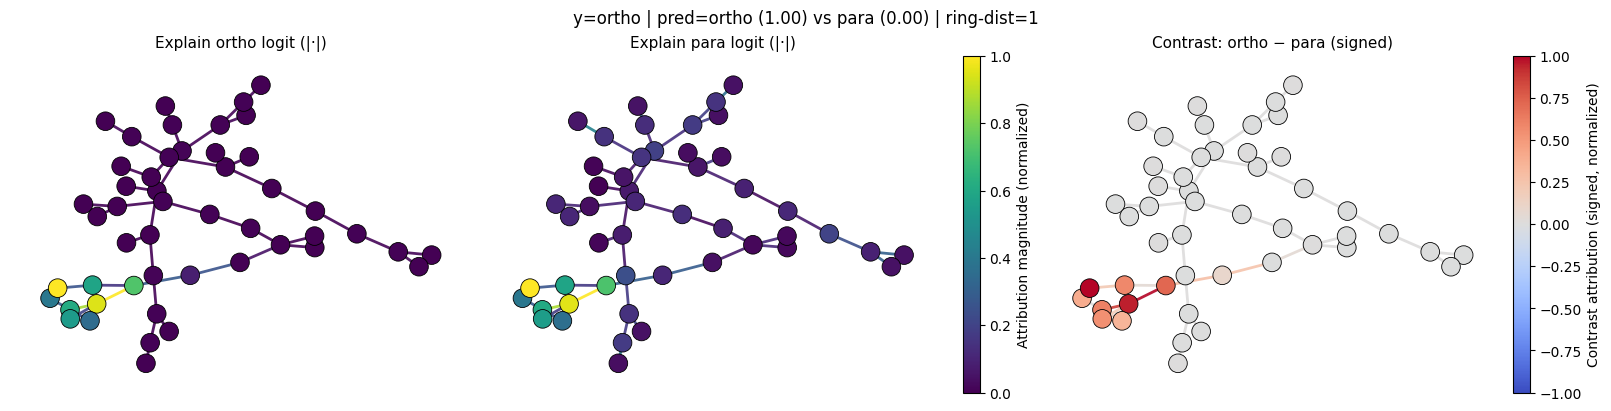

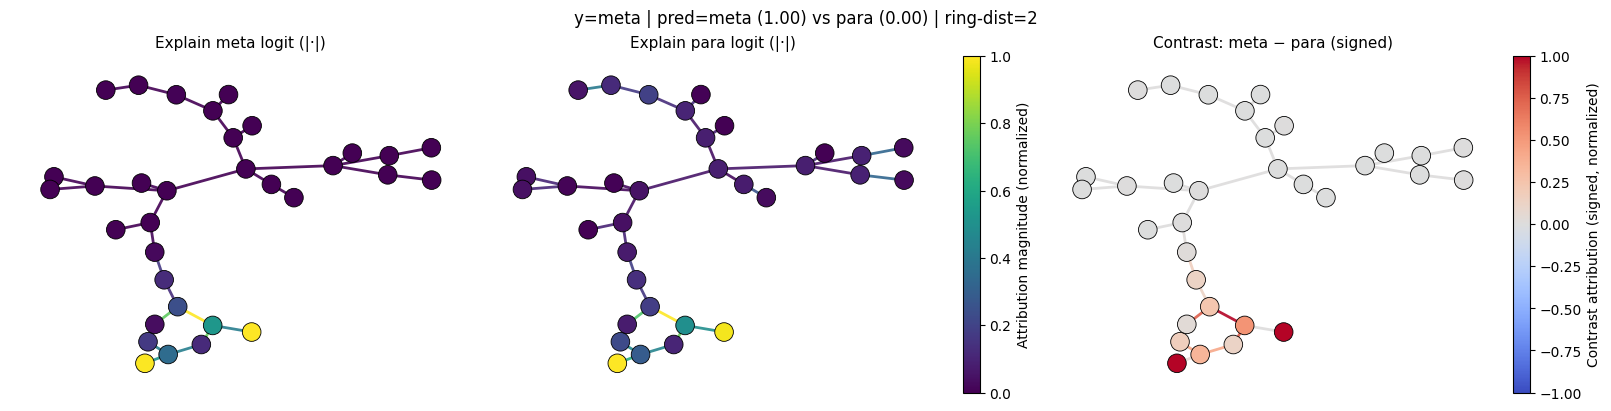

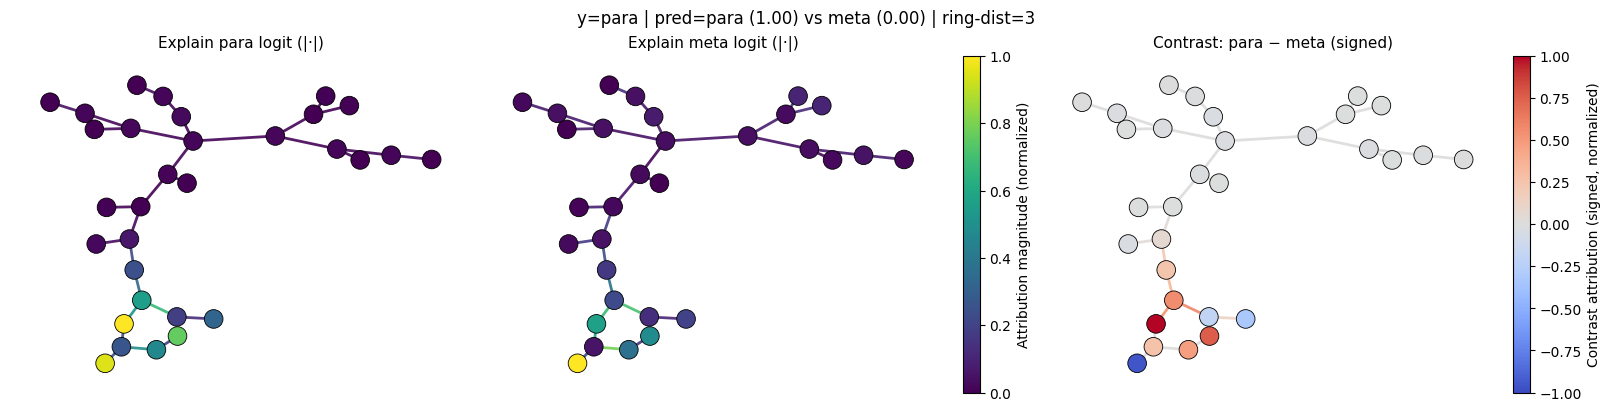

In [30]:
import importlib
import bcosgnn.explain_edge_attr as _explain_edge_attr
importlib.reload(_explain_edge_attr)
explain_edge_attr = _explain_edge_attr.explain

def ring_attachment_distance(data, ring_mask_attr: str = 'node_mask_full') -> int | None:
    """Return shortest-path distance on the ring between the two substituent attachment sites.

    Assumes the two substituents are leaf nodes (degree=1) attached to ring nodes in `ring_mask_attr`.
    """
    if not hasattr(data, ring_mask_attr):
        return None
    ring_mask = getattr(data, ring_mask_attr).detach().cpu().numpy().astype(bool).reshape(-1)
    if ring_mask.sum() == 0:
        return None
    G = to_networkx(data, to_undirected=True)
    deg = dict(G.degree())
    leaf_nodes = [n for n, d in deg.items() if d == 1]
    attach = []
    for leaf in leaf_nodes:
        nbrs = list(G.neighbors(leaf))
        if len(nbrs) != 1:
            continue
        nbr = nbrs[0]
        if 0 <= nbr < len(ring_mask) and ring_mask[nbr]:
            attach.append(nbr)
    attach = sorted(set(attach))
    if len(attach) != 2:
        return None
    ring_nodes = [i for i, m in enumerate(ring_mask) if m]
    H = G.subgraph(ring_nodes).copy()
    try:
        return int(nx.shortest_path_length(H, attach[0], attach[1]))
    except Exception:
        return None

def node_edge_scores_from_contrib(contrib: dict, *, normalize: bool = True):
    node_scores = node_scores_from_contrib(contrib['x'], mode='abs', normalize=normalize).detach().cpu().numpy().astype(float)
    if contrib.get('edge_attr', None) is None:
        edge_scores = None
    else:
        edge_scores = contrib['edge_attr'].detach().abs().sum(dim=-1).detach().cpu().numpy().astype(float)
        if normalize and edge_scores.size > 0:
            edge_scores = edge_scores - edge_scores.min()
            denom = edge_scores.max()
            if float(denom) > 0:
                edge_scores = edge_scores / denom
    return node_scores, edge_scores

def signed_node_scores_from_contrib(contrib_x: torch.Tensor):
    score = contrib_x.detach().sum(dim=-1)
    score = score.detach().cpu().numpy().astype(float)
    m = np.max(np.abs(score))
    if float(m) > 0:
        score = score / m
    return score

def signed_edge_scores_from_contrib(edge_contrib: torch.Tensor | None):
    if edge_contrib is None:
        return None
    score = edge_contrib.detach().sum(dim=-1)
    score = score.detach().cpu().numpy().astype(float)
    m = np.max(np.abs(score))
    if float(m) > 0:
        score = score / m
    return score

@torch.no_grad()
def logits_single(model: nn.Module, data) -> torch.Tensor:
    model.eval()
    data = data.to(DEVICE)
    batch = data.x.new_zeros(data.num_nodes, dtype=torch.long)
    return model(data.x, data.edge_index, data.edge_attr, batch).squeeze(0).detach().cpu()

def contrastive_contrib_single(model: nn.Module, data, *, winner: int, loser: int):
    model.eval()
    data = data.to(DEVICE)
    batch = data.x.new_zeros(data.num_nodes, dtype=torch.long)
    return explain_edge_attr(model, data.x, data.edge_index, data.edge_attr, batch, contrast=(int(winner), int(loser)))

def draw_panel_node_edge(ax, G, pos, *, node_vals, node_cmap, node_norm, edge_vals=None, edge_cmap=None, edge_norm=None, node_size=180, title=None):
    # edges first
    if edge_vals is not None:
        # edge_vals is per-directed-edge in PyG order; map to nx edges by taking max over both directions
        # build a dict for undirected edge score
        edge_index = np.array(list(G.edges()))
        # networkx gives undirected edges; we need look up in pyg edge_index
        # simplest: if E is directed, collapse by (min, max) in the same order as `data.edge_index`
        # here we pass pre-collapsed dict externally by supplying edge_vals as dict when needed
        if isinstance(edge_vals, dict):
            e_colors = [edge_cmap(edge_norm(edge_vals.get(tuple(sorted(e)), 0.0))) for e in edge_index]
            nx.draw_networkx_edges(G, pos, ax=ax, edge_color=e_colors, width=2.0, alpha=0.9)
        else:
            nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.35, width=1.0)
    else:
        nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.35, width=1.0)
    # nodes
    node_colors = [node_cmap(node_norm(v)) for v in node_vals]
    nx.draw_networkx_nodes(
        G, pos, ax=ax,
        node_color=node_colors,
        node_size=node_size,
        linewidths=0.6,
        edgecolors='k',
    )
    ax.set_axis_off()
    if title is not None:
        ax.set_title(title, fontsize=11)

def collapse_edge_scores_to_undirected(data, edge_scores_1d: np.ndarray) -> dict:
    """Collapse directed PyG edge scores to undirected (min(u,v), max(u,v)) -> max score."""
    src = data.edge_index[0].detach().cpu().numpy()
    dst = data.edge_index[1].detach().cpu().numpy()
    out = {}
    for s, t, v in zip(src, dst, edge_scores_1d.tolist()):
        key = tuple(sorted((int(s), int(t))))
        out[key] = max(float(v), out.get(key, 0.0))
    return out

def plot_contrastive_explanations(
    model: nn.Module,
    dataset,
    *,
    n_per_class: int = 2,
    seed: int = 0,
    node_size: int = 180,
 ):
    rng = random.Random(seed)
    by_class = defaultdict(list)
    for i, d in enumerate(dataset):
        by_class[int(d.y)].append(i)
    for c in by_class:
        rng.shuffle(by_class[c])

    node_cmap = plt.get_cmap('viridis')
    node_norm = mcolors.Normalize(vmin=0.0, vmax=1.0)
    div_cmap = plt.get_cmap('coolwarm')
    div_norm = mcolors.TwoSlopeNorm(vmin=-1.0, vcenter=0.0, vmax=1.0)

    for y in sorted(LABELS):
        idxs = by_class.get(y, [])[:n_per_class]
        for idx in idxs:
            d = dataset[idx]
            log = logits_single(model, d)
            probs = log.softmax(dim=-1)
            pred = int(probs.argmax().item())
            runner_up = int(torch.topk(probs, k=2).indices[1].item())
            dist = ring_attachment_distance(d, 'node_mask_full')
            dist_str = 'NA' if dist is None else str(dist)

            # class-conditional contribs
            scores_pred, contrib_pred, _ = explain_node_scores_single(model, d, normalize=True, target_mode='pred', return_target=True)
            contrib_alt = explain_edge_attr(
            	model, d.x.to(DEVICE), d.edge_index.to(DEVICE), d.edge_attr.to(DEVICE), d.x.new_zeros(d.num_nodes, dtype=torch.long).to(DEVICE), target=runner_up
            )
            node_alt, edge_alt = node_edge_scores_from_contrib(contrib_alt, normalize=True)
            edge_pred = None
            if contrib_pred.get('edge_attr', None) is not None:
                edge_pred = contrib_pred['edge_attr'].detach().abs().sum(dim=-1).detach().cpu().numpy().astype(float)
                edge_pred = edge_pred - edge_pred.min()
                denom = edge_pred.max()
                if float(denom) > 0:
                    edge_pred = edge_pred / denom

            # contrastive contrib (winner vs runner-up)
            c_contrast = contrastive_contrib_single(model, d, winner=pred, loser=runner_up)
            node_contrast = signed_node_scores_from_contrib(c_contrast['x'])
            edge_contrast = signed_edge_scores_from_contrib(c_contrast.get('edge_attr', None))

            # collapse edges to undirected dict for nx
            edge_pred_u = collapse_edge_scores_to_undirected(d, edge_pred) if edge_pred is not None else None
            edge_alt_u = collapse_edge_scores_to_undirected(d, edge_alt) if edge_alt is not None else None
            edge_contrast_u = collapse_edge_scores_to_undirected(d, edge_contrast) if edge_contrast is not None else None

            G = to_networkx(d, to_undirected=True)
            pos = nx.spring_layout(G, seed=0)
            fig, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)
            fig.suptitle(
            	f"y={LABELS[int(d.y)]} | pred={LABELS[pred]} ({float(probs[pred]):.2f}) vs {LABELS[runner_up]} ({float(probs[runner_up]):.2f}) | ring-dist={dist_str}",
            	fontsize=12,
            )

            # Panel 1: pred-class attribution (magnitude)
            node_pred = scores_pred.detach().cpu().numpy().astype(float).reshape(-1)
            node_pred = np.clip(node_pred, 0.0, 1.0)
            draw_panel_node_edge(
            	axes[0], G, pos,
            	node_vals=node_pred, node_cmap=node_cmap, node_norm=node_norm,
            	edge_vals=edge_pred_u, edge_cmap=node_cmap, edge_norm=node_norm,
            	node_size=node_size, title=f"Explain {LABELS[pred]} logit (|·|)",
            )

            # Panel 2: runner-up attribution (magnitude)
            node_alt = np.clip(node_alt.reshape(-1), 0.0, 1.0)
            draw_panel_node_edge(
            	axes[1], G, pos,
            	node_vals=node_alt, node_cmap=node_cmap, node_norm=node_norm,
            	edge_vals=edge_alt_u, edge_cmap=node_cmap, edge_norm=node_norm,
            	node_size=node_size, title=f"Explain {LABELS[runner_up]} logit (|·|)",
            )

            # Panel 3: contrastive attribution (signed)
            draw_panel_node_edge(
            	axes[2], G, pos,
            	node_vals=node_contrast.reshape(-1), node_cmap=div_cmap, node_norm=div_norm,
            	edge_vals=edge_contrast_u, edge_cmap=div_cmap, edge_norm=div_norm,
            	node_size=node_size, title=f"Contrast: {LABELS[pred]} − {LABELS[runner_up]} (signed)",
            )

            # colorbars
            sm_mag = cm.ScalarMappable(norm=node_norm, cmap=node_cmap); sm_mag.set_array([])
            sm_div = cm.ScalarMappable(norm=div_norm, cmap=div_cmap); sm_div.set_array([])
            cbar1 = fig.colorbar(sm_mag, ax=axes[:2], fraction=0.02, pad=0.02)
            cbar1.set_label('Attribution magnitude (normalized)')
            cbar2 = fig.colorbar(sm_div, ax=axes[2], fraction=0.06, pad=0.02)
            cbar2.set_label('Contrast attribution (signed, normalized)')
            plt.show()

plot_contrastive_explanations(model, test_data, n_per_class=1, seed=2)

In [ ]:
import numpy as np
import torch

def chlorine_nodes_from_core_mask(data) -> list[int]:
    if not hasattr(data, 'node_mask') or data.node_mask is None:
        return []
    core = torch.where(data.node_mask.view(-1) > 0.5)[0].detach().cpu().tolist()
    if len(core) == 0:
        return []
    G = to_networkx(data, to_undirected=True)
    deg = dict(G.degree(core))
    cl = [int(n) for n in core if int(deg.get(int(n), 0)) == 1]
    return sorted(cl)

def _ranks_desc(scores_1d: np.ndarray) -> np.ndarray:
    order = np.argsort(-scores_1d)
    ranks = np.empty_like(order)
    ranks[order] = np.arange(1, len(order) + 1)
    return ranks

def report_chlorine_ranks(model: nn.Module, data):
    p = predict_proba_single(model, data)
    pred = int(p.argmax())
    runner_up = int(np.argsort(-p.numpy())[1])
    dist = ring_attachment_distance(data, 'node_mask_full')
    cl_nodes = chlorine_nodes_from_core_mask(data)
    core = torch.where(data.node_mask.view(-1) > 0.5)[0].detach().cpu().tolist() if hasattr(data, 'node_mask') else []

    # class-conditional (pred logit) magnitude
    scores_pred, _, _ = explain_node_scores_single(model, data, normalize=True, target_mode='pred', return_target=True)
    s_pred = scores_pred.detach().cpu().numpy().astype(float).reshape(-1)
    r_pred = _ranks_desc(s_pred)

    # contrastive signed: take positive evidence for winner over runner-up
    c_contrast = contrastive_contrib_single(model, data, winner=pred, loser=runner_up)
    s_contrast_signed = signed_node_scores_from_contrib(c_contrast['x']).reshape(-1)  # in [-1,1]
    s_contrast_pos = np.clip(s_contrast_signed, 0.0, None)
    if float(s_contrast_pos.max()) > 0:
        s_contrast_pos = s_contrast_pos / float(s_contrast_pos.max())
    r_contrast = _ranks_desc(s_contrast_pos)

    def _fmt(nodes):
        return '[]' if not nodes else '[' + ', '.join(map(str, nodes)) + ']'

    print(f"y={LABELS[int(data.y)]} | pred={LABELS[pred]} ({float(p[pred]):.2f}) vs {LABELS[runner_up]} ({float(p[runner_up]):.2f}) | ring-dist={dist}")
    print(f"  core nodes={_fmt(core)} | cl nodes={_fmt(cl_nodes)}")
    if not cl_nodes:
        print("  (could not identify Cl nodes in this graph)")
        return
    for n in cl_nodes:
        print(f"  Cl node {n}: pred-rank={int(r_pred[n])} (score={s_pred[n]:.3f}) | contrast-rank={int(r_contrast[n])} (pos={s_contrast_pos[n]:.3f})")
    top2_pred = set(np.argsort(-s_pred)[:2].tolist())
    top2_contrast = set(np.argsort(-s_contrast_pos)[:2].tolist())
    print(f"  Cl-in-top2: pred={set(cl_nodes).issubset(top2_pred)} | contrast(pos)={set(cl_nodes).issubset(top2_contrast)}")

def chlorine_topk_stats(model: nn.Module, dataset, *, max_graphs: int = 200, k: int = 2, seed: int = 0):
    rng = random.Random(seed)
    idxs = list(range(len(dataset)))
    rng.shuffle(idxs)
    idxs = idxs[:max_graphs]

    n_used = 0
    both_in_topk_pred = 0
    both_in_topk_contrast = 0
    for i in idxs:
        d = dataset[i]
        cl = chlorine_nodes_from_core_mask(d)
        if len(cl) != 2:
            continue
        p = predict_proba_single(model, d)
        pred = int(p.argmax())
        runner_up = int(np.argsort(-p.numpy())[1])

        scores_pred, _, _ = explain_node_scores_single(model, d, normalize=False, target_mode='pred', return_target=True)
        s_pred = scores_pred.detach().cpu().numpy().astype(float).reshape(-1)
        topk_pred = set(np.argsort(-s_pred)[:k].tolist())

        c_contrast = contrastive_contrib_single(model, d, winner=pred, loser=runner_up)
        s_signed = signed_node_scores_from_contrib(c_contrast['x']).reshape(-1)
        s_pos = np.clip(s_signed, 0.0, None)
        topk_contrast = set(np.argsort(-s_pos)[:k].tolist())

        n_used += 1
        if set(cl).issubset(topk_pred):
            both_in_topk_pred += 1
        if set(cl).issubset(topk_contrast):
            both_in_topk_contrast += 1

    if n_used == 0:
        return None
    return {
        'n_used': n_used,
        'k': k,
        'pred_topk_frac': both_in_topk_pred / n_used,
        'contrast_topk_frac': both_in_topk_contrast / n_used,
    }

# Example: inspect a few graphs (one per class)
for cls in sorted(LABELS):
    idxs = pick_n_indices_for_class(test_data, cls, n=1, seed=7)
    if not idxs:
        continue
    print('-' * 80)
    report_chlorine_ranks(model, test_data[idxs[0]])

print('-' * 80)
print('Dataset-level chlorine-in-topk stats (heuristic Cl nodes):')
print(chlorine_topk_stats(model, test_data, max_graphs=200, k=2, seed=0))

--------------------------------------------------------------------------------
y=ortho | pred=ortho (1.00) vs para (0.00) | ring-dist=1
  core nodes=[26, 27, 31, 32] | cl nodes=[31, 32]
  Cl node 31: pred-rank=6 (score=0.544) | contrast-rank=6 (pos=0.544)
  Cl node 32: pred-rank=8 (score=0.349) | contrast-rank=8 (pos=0.350)
  Cl-in-top2: pred=False | contrast(pos)=False
--------------------------------------------------------------------------------
y=meta | pred=meta (1.00) vs para (0.00) | ring-dist=2
  core nodes=[39, 41, 44, 45] | cl nodes=[44, 45]
  Cl node 44: pred-rank=1 (score=1.000) | contrast-rank=1 (pos=1.000)
  Cl node 45: pred-rank=2 (score=0.991) | contrast-rank=2 (pos=0.991)
  Cl-in-top2: pred=True | contrast(pos)=True
--------------------------------------------------------------------------------
y=para | pred=para (1.00) vs meta (0.00) | ring-dist=3
  core nodes=[42, 45, 47, 48] | cl nodes=[47, 48]
  Cl node 47: pred-rank=6 (score=0.325) | contrast-rank=48 (pos=0.00

/tmp/ipykernel_59217/1998931683.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


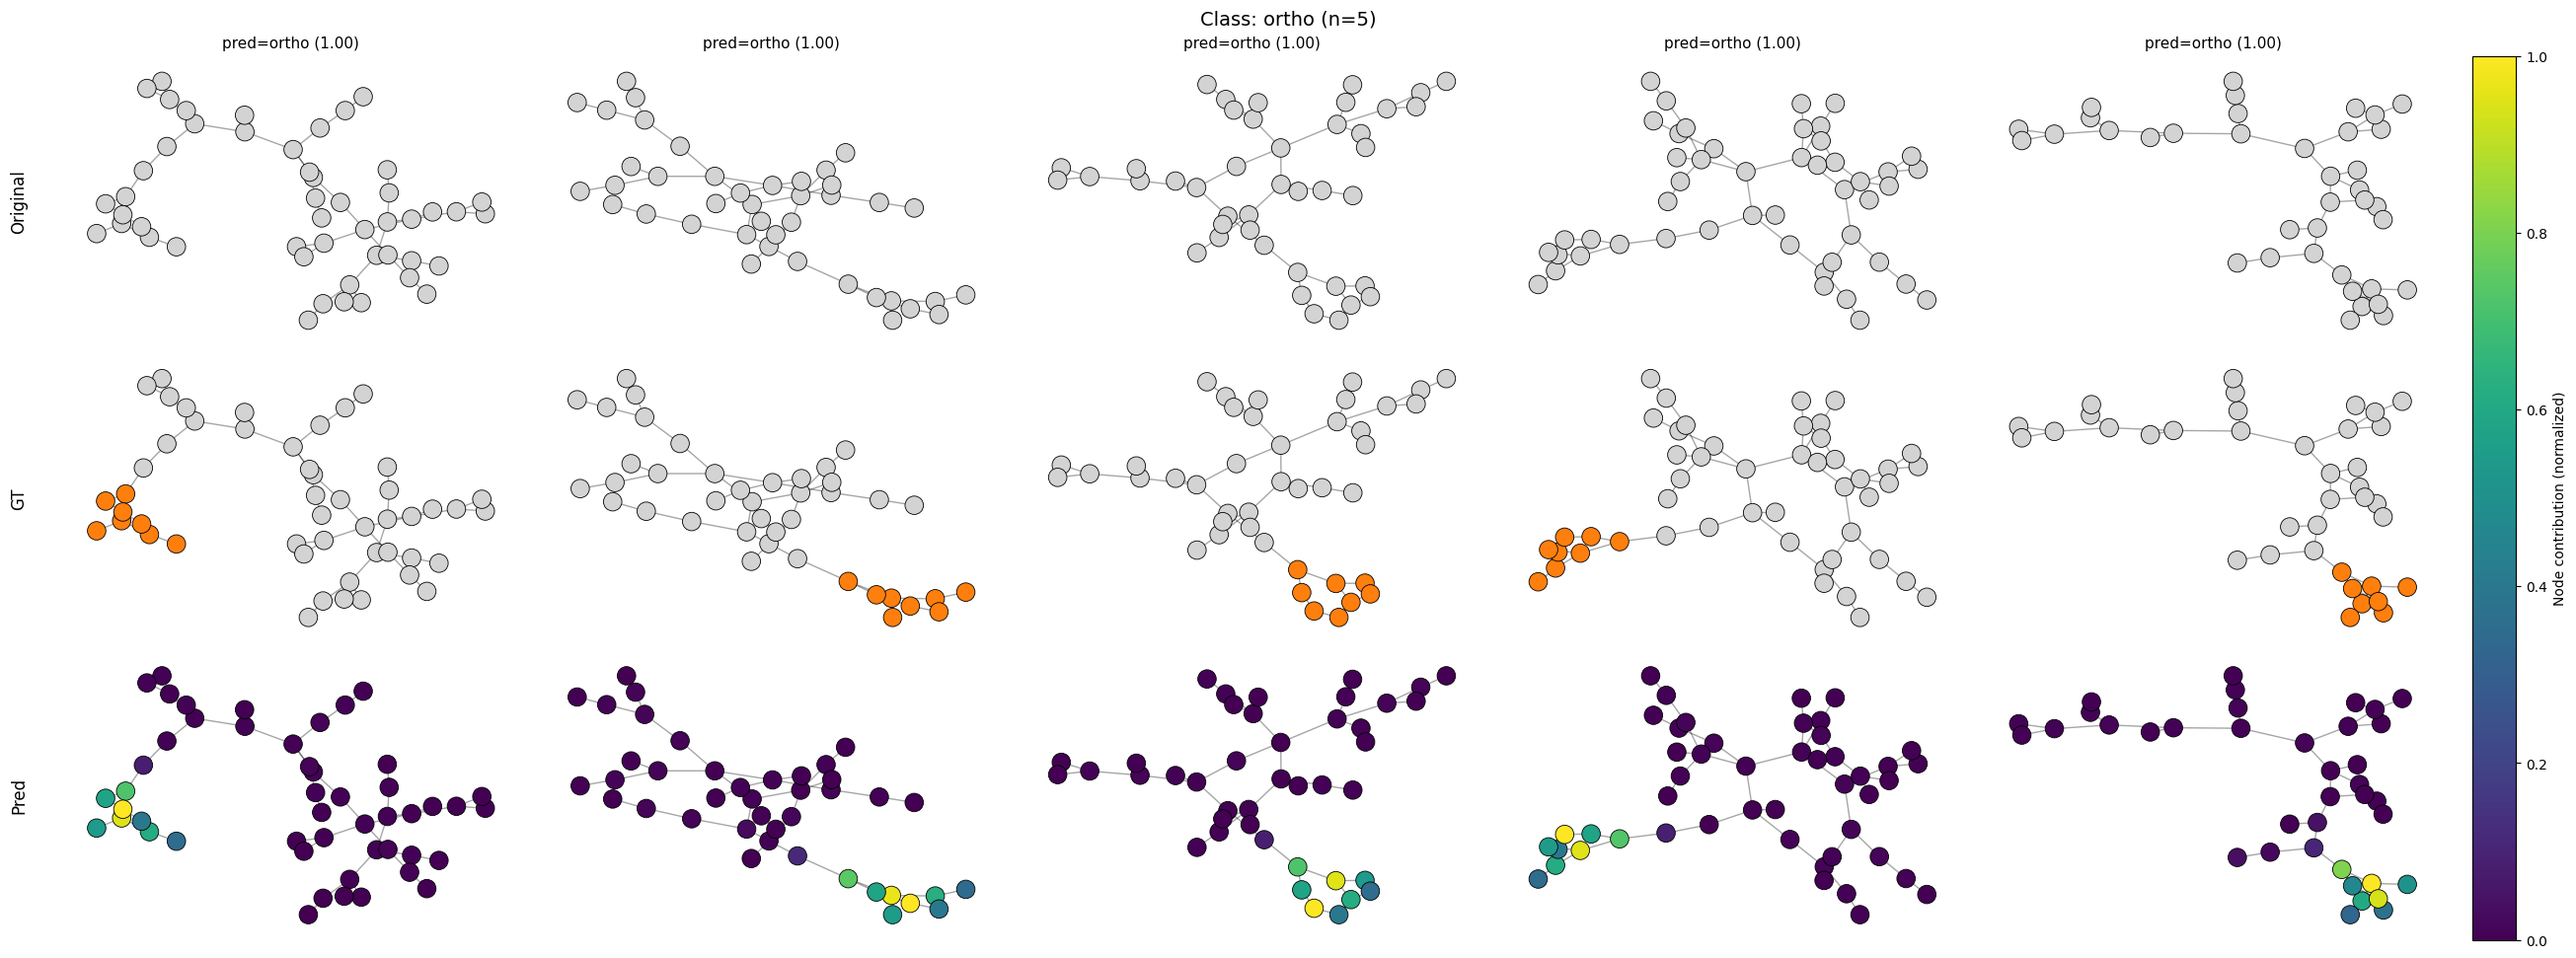

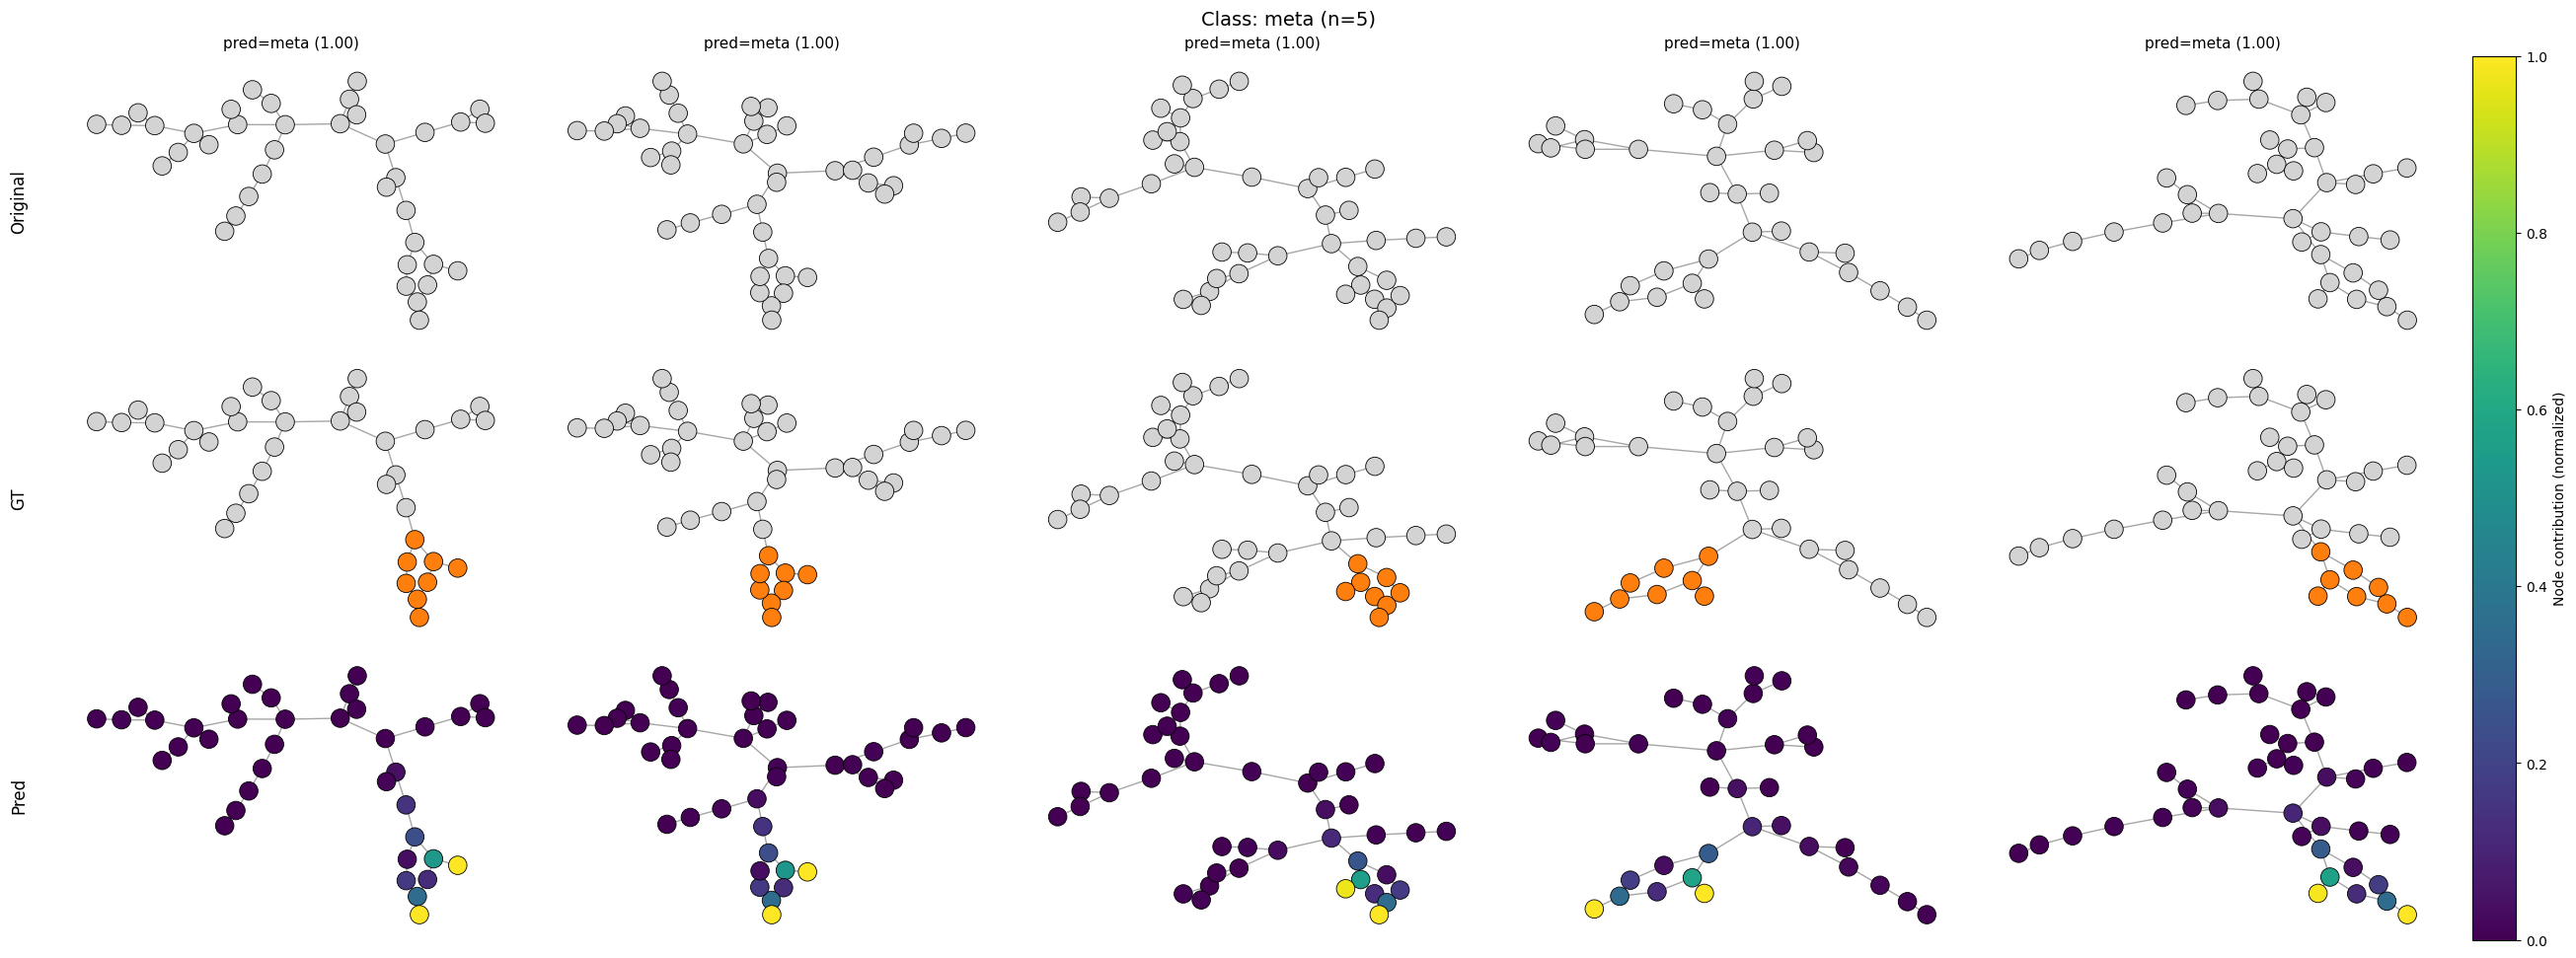

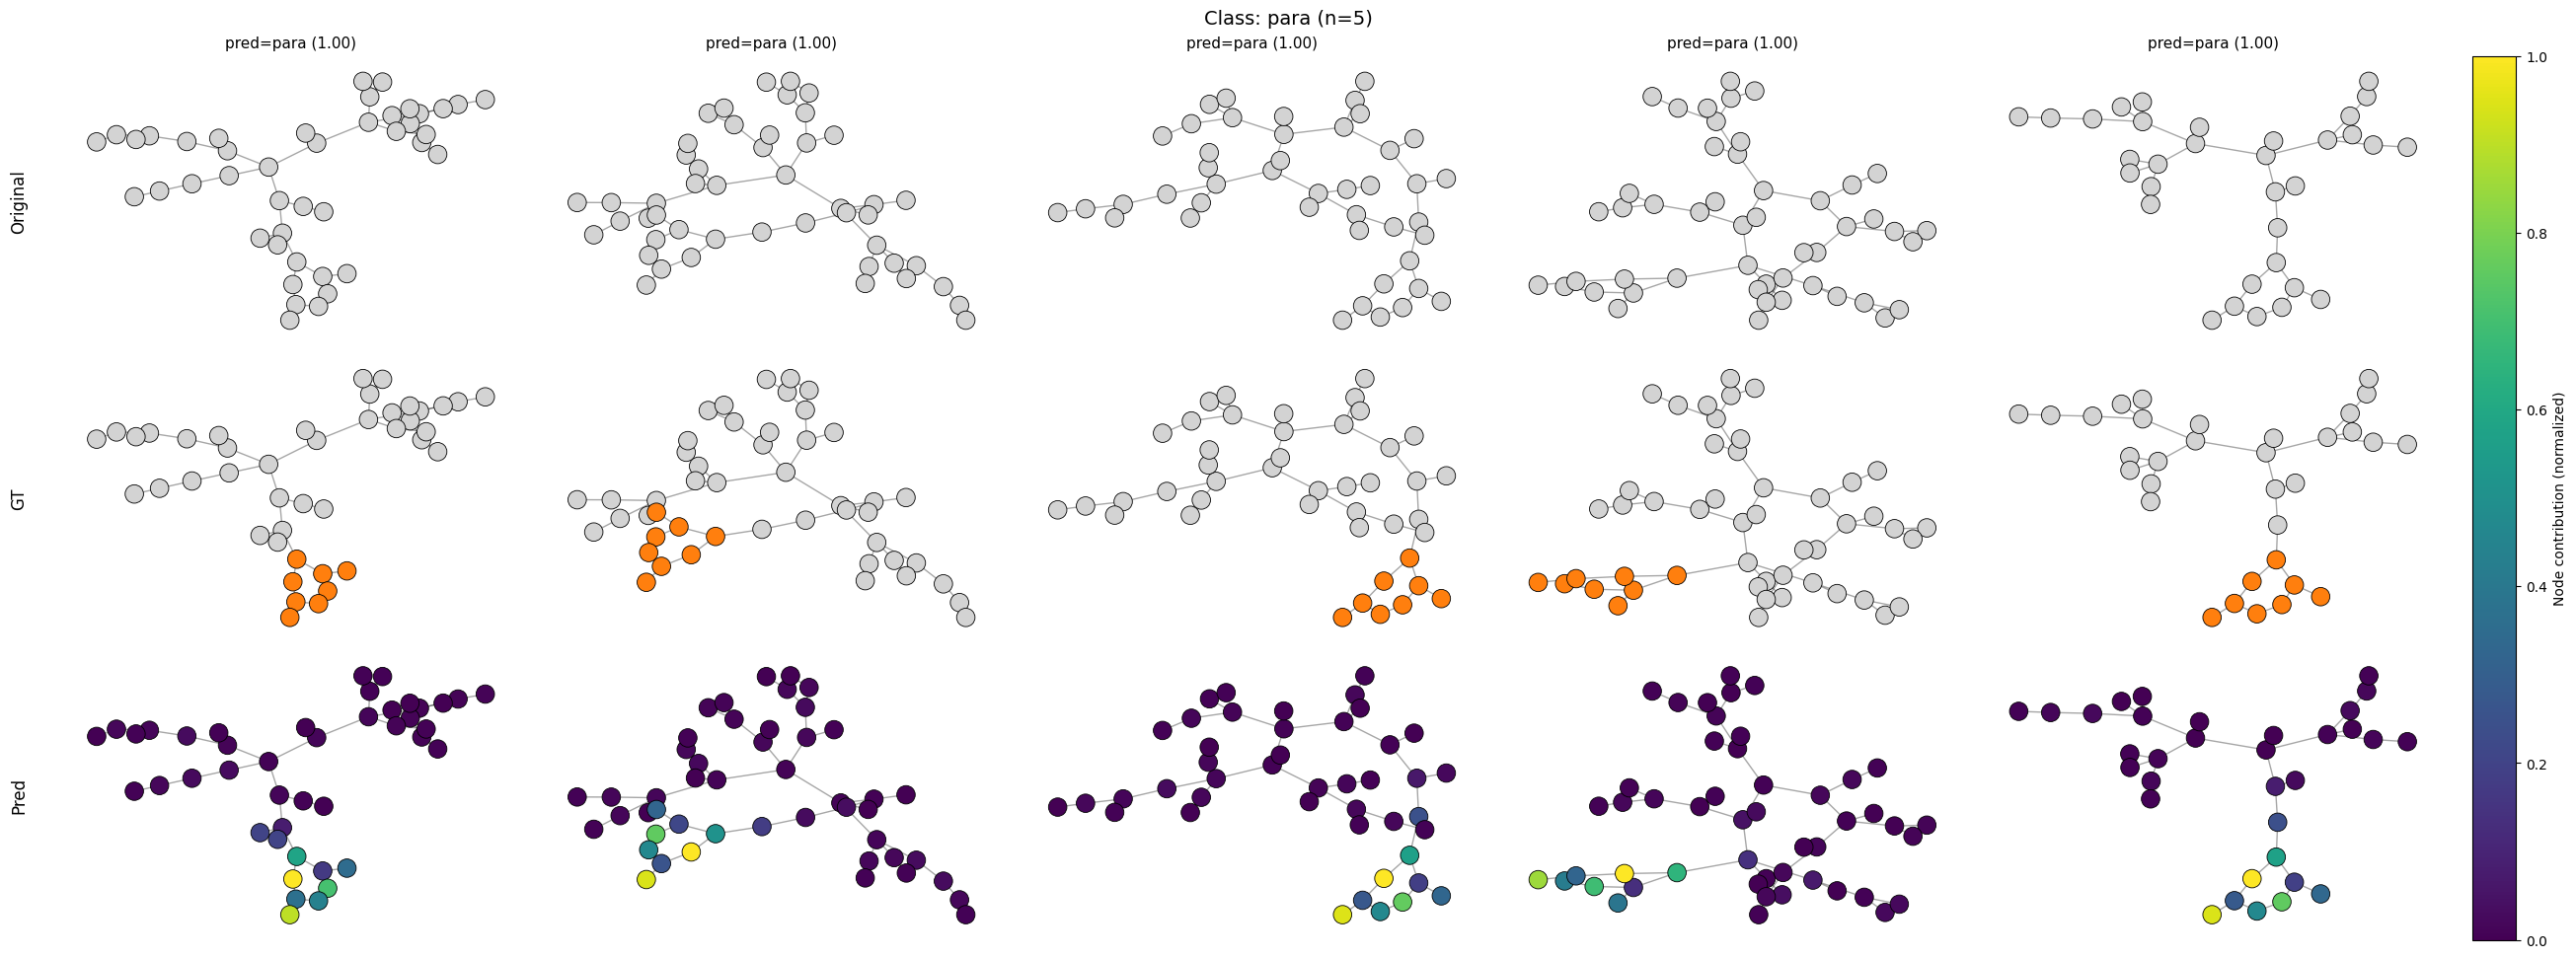

In [ ]:

import matplotlib.cm as cm
import matplotlib.colors as mcolors

def pick_n_indices_for_class(dataset, cls: int, n: int = 5, seed: int = 1):
    rng = random.Random(seed + 1337 * int(cls))
    idxs = [i for i, d in enumerate(dataset) if int(d.y) == int(cls)]
    rng.shuffle(idxs)
    return idxs[:n]

def draw_panel(ax, G, pos, *, node_colors, node_size=180, title=None):
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.35, width=1.0)
    nx.draw_networkx_nodes(
        G, pos, ax=ax,
        node_color=node_colors,
        node_size=node_size,
        linewidths=0.6,
        edgecolors='k',
    )
    ax.set_axis_off()
    if title is not None:
        ax.set_title(title, fontsize=11)

def plot_explanations_per_class(
    model: nn.Module,
    dataset,
    *,
    gt_mask_attr: str = 'node_mask_full',
    n_per_class: int = 5,
    seed: int = 1,
    node_size: int = 180,
    cmap_name: str = 'viridis',
    figsize_per_col=(5.2, 3.2),
    ):
    cmap = cm.get_cmap(cmap_name)
    norm = mcolors.Normalize(vmin=0.0, vmax=1.0)
    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    for cls in sorted(LABELS):
        idxs = pick_n_indices_for_class(dataset, cls, n=n_per_class, seed=seed)
        n_cols = len(idxs)
        fig_w = figsize_per_col[0] * n_cols
        fig_h = figsize_per_col[1] * 3
        fig, axes = plt.subplots(3, n_cols, figsize=(fig_w, fig_h), constrained_layout=True)
        if n_cols == 1:
            axes = np.array(axes).reshape(3, 1)

        for col, i in enumerate(idxs):
            d = dataset[i]
            scores_t, _ = explain_node_scores_single(model, d)
            scores = scores_t.detach().cpu().numpy().astype(float).reshape(-1)
            scores = np.clip(scores, 0.0, 1.0)

            gt_mask = getattr(d, gt_mask_attr).detach().cpu().numpy().astype(int).reshape(-1)

            p = predict_proba_single(model, d)
            pred_lab = LABELS.get(int(p.argmax()), str(int(p.argmax())))
            title = f"pred={pred_lab} ({float(p.max()):.2f})"

            G = to_networkx(d, to_undirected=True)
            pos = nx.spring_layout(G, seed=0)

            # Row 1: original
            draw_panel(axes[0, col], G, pos, node_colors=['lightgray'] * d.num_nodes, node_size=node_size, title=title)

            # Row 2: GT highlighted
            gt_colors = ['tab:orange' if gt_mask[n] == 1 else 'lightgray' for n in range(d.num_nodes)]
            draw_panel(axes[1, col], G, pos, node_colors=gt_colors, node_size=node_size)

            # Row 3: ALL nodes colored by importance score
            pred_colors = [cmap(norm(scores[n])) for n in range(d.num_nodes)]
            draw_panel(axes[2, col], G, pos, node_colors=pred_colors, node_size=node_size)

        # Row labels on first column
        axes[0, 0].text(-0.06, 0.5, 'Original', transform=axes[0, 0].transAxes, rotation=90, va='center', ha='right', fontsize=12)
        axes[1, 0].text(-0.06, 0.5, 'GT', transform=axes[1, 0].transAxes, rotation=90, va='center', ha='right', fontsize=12)
        axes[2, 0].text(-0.06, 0.5, 'Pred', transform=axes[2, 0].transAxes, rotation=90, va='center', ha='right', fontsize=12)

        fig.suptitle(f"Class: {LABELS.get(cls, str(cls))} (n={n_cols})", fontsize=14)
        cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), fraction=0.02, pad=0.01)
        cbar.set_label('Node contribution (normalized)', rotation=90)
        plt.show()

plot_explanations_per_class(model, test_data, gt_mask_attr='node_mask_full', n_per_class=5, seed=1)